In [174]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [175]:
credit_card_data=pd.read_csv("creditcard.csv")
credit_card_data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [176]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [177]:
credit_card_data.shape

(284807, 31)

In [178]:
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [179]:
credit_card_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [180]:
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [ ]:
legit=credit_card_data[credit_card_data.Class==0]
fraud=credit_card_data[credit_card_data.Class==1]

In [182]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


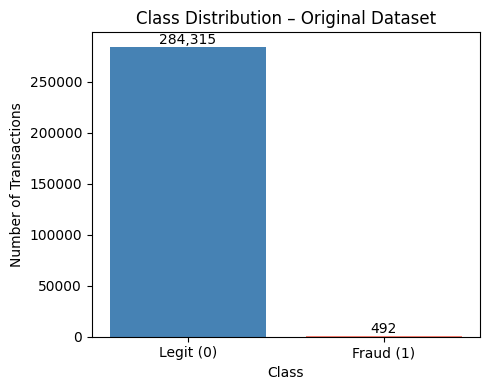

In [208]:

import matplotlib.pyplot as plt


class_counts = credit_card_data['Class'].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(['Legit (0)', 'Fraud (1)'], class_counts.values,
        color=['steelblue', 'salmon'])

plt.title('Class Distribution – Original Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')


for i, v in enumerate(class_counts.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [184]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [185]:
# compare the values for both transactions 
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,-0.006576,0.010832,0.000189,0.012064,0.000161,0.007164,0.011535,0.003887,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Its undersmpling so building a sample dataset 

fraud transaction count -- >49

In [186]:
legit_sample=legit.sample(n=492)

In [187]:
new_dataset=pd.concat([legit_sample,fraud],axis=0) #adding row wise
new_dataset.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
27627,34634.0,0.333499,1.699873,-2.596561,3.643945,-0.585068,-0.654659,-2.275789,0.675229,-2.042416,-2.834871,2.802005,-4.392732,-1.369671,-5.327287,0.163159,-1.359389,-5.095183,-0.338013,-0.124138,0.329342,0.469212,-0.144363,-0.317981,-0.769644,0.807855,0.228164,0.551002,0.305473,18.96,1
42367,41074.0,-0.210642,0.677066,0.769884,-0.981818,0.265093,-1.213108,1.084314,-0.203697,-0.781810,-0.499406,1.533590,1.263921,0.641810,0.357737,-0.797018,0.383117,-0.769203,-0.568887,-0.187106,-0.037868,-0.159976,-0.598011,0.391054,0.547785,-1.412690,0.231733,0.105225,0.215386,34.90,0
199181,132844.0,0.037726,0.885038,0.297772,-0.596567,0.461205,-1.028412,1.026881,-0.201617,-0.097803,-0.430479,-0.818506,0.336834,0.344393,0.050543,-0.393154,-0.167415,-0.371688,-0.878693,-0.158326,-0.022885,-0.250702,-0.519799,0.073256,-0.010947,-0.492770,0.142256,0.252461,0.097542,3.96,0
83297,59777.0,-8.257111,-4.814461,-5.365307,1.204230,-3.347420,-1.331601,-1.967893,1.295438,-1.674415,-3.426052,0.144563,-4.283529,-0.240895,-3.657490,0.923105,0.844221,-3.948312,-1.807516,0.105879,-1.233987,0.436390,-0.077553,-3.091624,-0.390201,-0.288689,-0.340004,0.039819,-1.007900,319.20,1
233258,147501.0,-1.611877,-0.408410,-3.829762,6.249462,-3.360922,1.147964,1.858425,0.474858,-3.838399,-1.445375,2.113900,-3.259702,-0.315347,-1.808103,-0.741877,-2.986920,-4.815863,-1.271655,1.701685,2.425677,1.245582,0.616383,2.251439,-0.066096,0.538710,0.541325,-0.136243,-0.009852,996.27,1


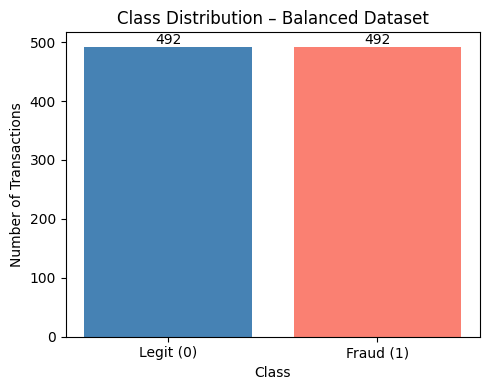

In [209]:

import matplotlib.pyplot as plt

# Count classes in balanced dataset
class_counts = new_dataset['Class'].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(['Legit (0)', 'Fraud (1)'],
        class_counts.values,
        color=['steelblue', 'salmon'])

plt.title('Class Distribution – Balanced Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')

# Add count labels on bars
for i, v in enumerate(class_counts.values):
    plt.text(i, v, f'{v}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



C:\Users\Akash.Aswar\AppData\Local\Temp\ipykernel_15836\1333178768.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


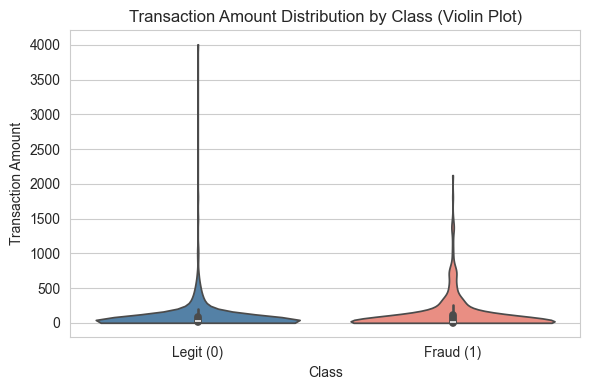

In [211]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(6,4))
sns.violinplot(
    x='Class',
    y='Amount',
    data=new_dataset,
    palette=['steelblue', 'salmon'],
    cut=0
)

plt.xticks([0, 1], ['Legit (0)', 'Fraud (1)'])
plt.title('Transaction Amount Distribution by Class (Violin Plot)')
plt.xlabel('Class')
plt.ylabel('Transaction Amount')

plt.tight_layout()
plt.show()


In [188]:
new_dataset['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [189]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,95770.686992,-0.099095,0.045034,-0.088395,0.051221,-0.052988,-0.068393,-0.063309,-0.006908,-0.034953,-0.043786,-0.022711,0.017474,0.069526,0.000287,0.037087,-0.006818,0.025023,0.060866,-0.032934,-0.021895,0.046618,0.002032,-0.004602,0.054631,-0.015128,0.014854,0.005123,-0.004704,90.476931
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [222]:
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,-0.006576,0.010832,0.000189,0.012064,0.000161,0.007164,0.011535,0.003887,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


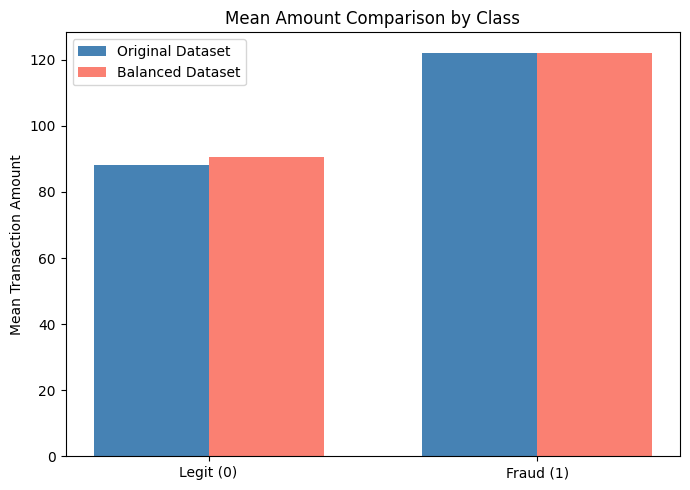

In [210]:

import matplotlib.pyplot as plt
import numpy as np

# Calculate mean values grouped by class
orig_mean = credit_card_data.groupby('Class').mean()['Amount']
new_mean = new_dataset.groupby('Class').mean()['Amount']

labels = ['Legit (0)', 'Fraud (1)']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, orig_mean.values, width, label='Original Dataset', color='steelblue')
plt.bar(x + width/2, new_mean.values, width, label='Balanced Dataset', color='salmon')

plt.xticks(x, labels)
plt.ylabel('Mean Transaction Amount')
plt.title('Mean Amount Comparison by Class')
plt.legend()

plt.tight_layout()
plt.show()


In [190]:
# Splitting the data into features and targets 

X=new_dataset.drop(columns='Class',axis=1)
y=new_dataset['Class']

In [191]:
X.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

In [192]:
# Splitting into training and testing 
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,stratify=y,random_state=2)

In [193]:
print(X.shape,xtrain.shape,xtest.shape)

(984, 30) (787, 30) (197, 30)


In [194]:
# Model training : Logistic Regression : 
model=LogisticRegression()


In [195]:
model.fit(xtrain,ytrain)

c:\Users\Akash.Aswar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [196]:
# Accuracy score on training data : 
xtrain_predict=model.predict(xtrain)
training_data_accuracy=accuracy_score(xtrain_predict,ytrain)


In [197]:
# Accuracy score on test data : 
xtest_predict=model.predict(xtest)
testing_data_accuracy=accuracy_score(xtest_predict,ytest)

In [198]:
print("Training data accuracy : ",training_data_accuracy)
print("Testing data accuracy : ",testing_data_accuracy)

Training data accuracy :  0.9377382465057179
Testing data accuracy :  0.9238578680203046


In [199]:
from xgboost import XGBClassifier

In [ ]:
xgb_model=XGBClassifier(
    n_estimators=4000,
    learning_rate=0.01,
    max_depth=10,
    random_state=42,
    eval_metric="logloss"
)

In [201]:
from sklearn.metrics import accuracy_score
xgb_model.fit(xtrain,ytrain)
ypred=xgb_model.predict(xtest)
print("Accuracy : ",accuracy_score(ytest,ypred))

Accuracy :  0.9390862944162437


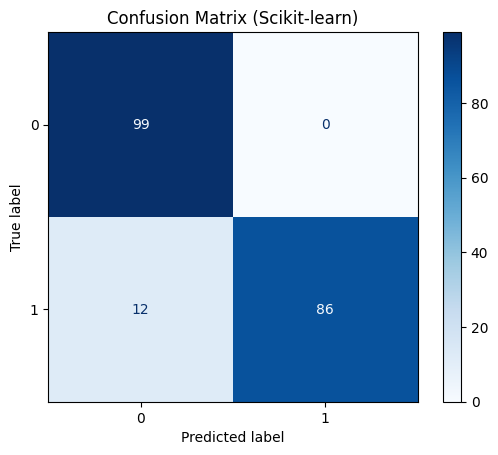

In [202]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(ytest, ypred, labels=xgb_model.classes_)

class_names = new_dataset["Class"].unique()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Scikit-learn)")
plt.show()

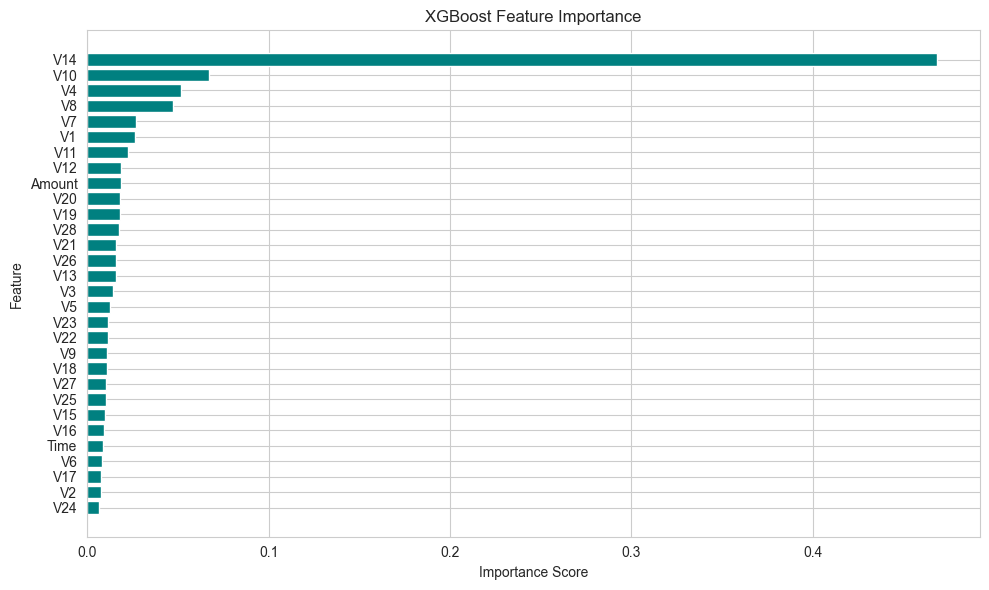

In [213]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature importances from trained model
importances = xgb_model.feature_importances_

# Create dataframe for plotting
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()
